**Introduction and Background**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#The dataset was too large to upload to github

%env KAGGLE_USERNAME = mckharris
%env KAGGLE_KEY = XXXXX

!kaggle datasets download -d samratp/bikeshare-analysis
!unzip -q bikeshare-analysis.zip

In [ ]:
NYC = pd.read_csv("NYC-CitiBike-2016.csv")

I imagine that my client is a US city's Department of Transportation (other than NYC). The city is experiencing congestion due to high activity of motor vehicles on roads and not enough utilization of public transit. The DoT would like to encourage their residents to start using other modes of transportation, such as bikes. The DoT comes to us, a public transit consulting group, to see if this is feasible. We decide to study the use of bikes in similar cities to see if this is an avenue the DoT should pursue.

The bikeshare dataset was uploaded to Kaggle by Samrat Pandiri, a professional affiliated with the data and software company Teradata. In the acknowledgments section on Kaggle, Pandiri noted that the data originally was sourced from Udacity, an online education platform owned by the consulting firm Accenture. Further investigation revealed that each dataset was created by a distinct, privately operated bikeshare company. New York City's data came from Citi Bike, which operates throughout NYC and parts of New Jersey. The most plausible explanation for how this data ended up on Kaggle is that Accenture obtained the datasets from these individual bikeshare companies for consulting purposes. Once their work was complete, they made the data available through Udacity’s subscription-based data platform.

This dataset was of specific interest to our consulting group for several reasons. First, the data contains a broad pool of points from which to refine our conclusions. This dataset also pulls from three highly populated US cities (particularly New York City). It includes predictors related to the locations of the biking routes. Finally, many of the predictors center around consumer data, allowing our company to not only extract information about the use of bikes, but the individuals who use the bikes.

My consulting stressed the importance of acknowledging that the consumer data reflected real individuals and that their privacy and autonomy must be respected; when conducting this analysis, proper measures and strategies were taken ensure that all experimentation was unbiased and ethical. For example, all consumer data was made numerical if it wasn't already--making the human identities of the datapoints untraceable.

For the purposes of this research, my consulting group decided to primarily focus on the New York City region. As reported by the U.S. Department of Transportation, this city has the highest use of bikeshares (https://data.bts.gov/stories/s/Bikeshare-and-e-scooters-in-the-U-S-/fwcs-jprj/#:~:text=Looking%20at%20the%20remaining%2053,having%2010%20or%20fewer%20stations). Hence, I focused on this region to advise our client on how to further promote bikeshare services in the same way New York City does.

Duration: How long the bikes was in use, recorded in seconds. This is a numerical value.

State date: The day and time in which the bike started to be used. This is a date value.

End date: The day and time in which the bike stopped being used.This is a date value.

Start station number: The unique label associated with the station in which the bike was picked up from. This is a numerical value.

Start station: The cross street in which the bike was picked up from. This is a string (text).

End station number: The unique label associated with the station in which the bike was dropped off at. This is a numerical value.

End station: The cross street in which the bike was dropped off at. This is a string (text).

Bike number: the unique label associated with the bike. This is a string (text).

Member type: Whether the rider is a member of the bikeshare's company. This is a categorical value.

start station latitude: The latudial location of the bike's starting location. This is a numerical value.

start station longitude: The longitudal location of the bike's starting location. This is a numerical value.

end station latitude: The latudial location of the bike's ending location. This is a numerical value.

end station longitude: The longitudal location of the bike's ending location. This is a numerical value.

birth year: the year in which the rider was born. This is a numerical value

gender: the gender identity of the rider. This is a categorical value.

I've decided to not remove any variables from the datasets. Not all of the datasets have the same predictors, and so not every aspect of each dataset can be compared the other datasets. However, each dataset's predictors allow for very specific insights to be extracted, which could ultimately help the Department of Transportation make a more educated decision. If my consulting group finds some variables to be irrelevant during the study or that our model is overfitting, given proper justification, said variable will be removed.

In [ ]:
#Changing observation names
NYC["usertype"] = NYC["usertype"].replace("Customer", "Casual")
NYC["gender_Male"] = (NYC["gender"] == 0).astype(int)
NYC["gender_Female"] = (NYC["gender"] == 1).astype(int)

In [ ]:
NYC = NYC.drop(columns=['gender'])
NYC.head()
#NYC.dtypes

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender_Male,gender_Female
0,839,1/1/2016 00:09:55,1/1/2016 00:23:54,532,S 5 Pl & S 4 St,40.710451,-73.960876,401,Allen St & Rivington St,40.720196,-73.989978,17109,Casual,NaN,1,0
1,686,1/1/2016 00:21:17,1/1/2016 00:32:44,3143,5 Ave & E 78 St,40.776829,-73.963888,3132,E 59 St & Madison Ave,40.763505,-73.971092,23514,Subscriber,1960.0,0,1
2,315,1/1/2016 00:33:11,1/1/2016 00:38:26,3164,Columbus Ave & W 72 St,40.777057,-73.978985,3178,Riverside Dr & W 78 St,40.784145,-73.983625,14536,Subscriber,1971.0,0,1
3,739,1/1/2016 00:40:51,1/1/2016 00:53:11,223,W 13 St & 7 Ave,40.737815,-73.999947,276,Duane St & Greenwich St,40.717488,-74.010455,24062,Subscriber,1969.0,0,1
4,1253,1/1/2016 00:44:16,1/1/2016 01:05:09,484,W 44 St & 5 Ave,40.755003,-73.980144,151,Cleveland Pl & Spring St,40.722104,-73.997249,16380,Casual,NaN,1,0


In [ ]:
NYC = pd.read_csv("NYC-CitiBike-2016.csv")

In [ ]:
NYC["usertype"] = NYC["usertype"].replace("Customer", "Casual")
NYC = pd.get_dummies(NYC, columns=['usertype'], prefix='usertype', drop_first=True)
NYC = pd.get_dummies(NYC, columns=['gender'], prefix='gender', drop_first=True)
NYC['is_customer'] = (NYC['usertype_Subscriber'] == 1).astype(int)
NYC['gender_1'] = NYC['gender_1'].astype(int)
NYC = NYC.drop(columns = ['usertype_Subscriber', 'gender_2'])
NYC.rename(columns={'is_customer': 'user_type'}, inplace=True)

In [ ]:
NYC['starttime'] = pd.to_datetime(NYC['starttime'])
NYC['stoptime'] = pd.to_datetime(NYC['stoptime'])
NYC['start_hour'] = NYC['starttime'].dt.hour
NYC['start_minute'] = NYC['starttime'].dt.minute
NYC['start_day'] = NYC['starttime'].dt.day
NYC['start_month'] = NYC['starttime'].dt.month
NYC['start_year'] = NYC['starttime'].dt.year

NYC['stop_hour'] = NYC['stoptime'].dt.hour
NYC['stop_minute'] = NYC['stoptime'].dt.minute
NYC['stop_day'] = NYC['stoptime'].dt.day
NYC['stop_month'] = NYC['stoptime'].dt.month
NYC['stop_year'] = NYC['stoptime'].dt.year

NYC = NYC.drop(columns=['starttime'])
NYC = NYC.drop(columns=['stoptime'])
NYC = NYC.drop(columns=['start station name'])
NYC = NYC.drop(columns=['end station name'])

NYC = NYC.dropna()

In [ ]:
cols = ['bikeid'] + [col for col in NYC.columns if col != 'bikeid']
NYC = NYC[cols]

cols = ['user_type'] + [col for col in NYC.columns if col != 'user_type']
NYC = NYC[cols]

In [ ]:
NYC.head()

,user_type,bikeid,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,birth year,...,start_hour,start_minute,start_day,start_month,start_year,stop_hour,stop_minute,stop_day,stop_month,stop_year
1,1,23514,686,3143,40.776829,-73.963888,3132,40.763505,-73.971092,1960.0,...,0,21,1,1,2016,0,32,1,1,2016
2,1,14536,315,3164,40.777057,-73.978985,3178,40.784145,-73.983625,1971.0,...,0,33,1,1,2016,0,38,1,1,2016
3,1,24062,739,223,40.737815,-73.999947,276,40.717488,-74.010455,1969.0,...,0,40,1,1,2016,0,53,1,1,2016
5,1,22823,525,474,40.745168,-73.986831,470,40.743453,-74.000040,1975.0,...,0,47,1,1,2016,0,55,1,1,2016
6,1,18602,659,387,40.712733,-74.004607,377,40.722438,-74.005664,1991.0,...,0,55,1,1,2016,1,6,1,1,2016


Remove outliers

In [ ]:
Q1 = NYC['tripduration'].quantile(0.25)
Q3 = NYC['tripduration'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

NYC = NYC[(NYC['tripduration'] >= lower_bound) & (NYC['tripduration'] <= upper_bound)]

Baseline random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint

In [ ]:
X  = NYC.drop(columns = ["tripduration", "start_hour", "start_minute", "stop_hour", "stop_minute"])
y = NYC["tripduration"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
rf = RandomForestRegressor(max_depth = 20, random_state=42)

In [ ]:
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE: ", mse)
print("R^2 Score: ", r2)

MSE:  48258.844090557635
R^2 Score:  0.6905233109688482


Log transform Y so that relationship between X and y is more linear!

In [ ]:
y_log = np.log1p(y)

In [ ]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42)

In [ ]:
rf.fit(X_train, y_train_log)

RandomForestRegressor(max_depth=20, random_state=42)

In [ ]:
y_pred_log = rf.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test_log, y_pred_log)
r2 = r2_score(y_test_log, y_pred_log)

print("MSE: ", mse)
print("R^2 Score: ", r2)

# 0.12833 = 1.7 seconds

MSE:  0.1283333490931037
R^2 Score:  0.6825266680370543


Grid Search to optimize hyperparameters

In [ ]:
rf2 = RandomForestRegressor(random_state=42) #remove max_depth!

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=rf2,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_search.fit(X_train, y_train_log)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [ ]:
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validated score:", grid_search.best_score_)

Best parameters found: {'max_depth': 30, 'n_estimators': 200}
Best cross-validated score: -0.35212391936546633


In [ ]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test_log, y_pred)
r2 = r2_score(y_test_log, y_pred)

print("MSE: ", mse) #1.1242 seconds
print("R^2 Score: ", r2)

MSE:  0.11714229672400896
R^2 Score:  0.7102112933421323


In [ ]:
param_grid = {
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

In [ ]:
rf3 = RandomForestRegressor(max_depth = 30, n_estimators = 200, random_state=42)

In [ ]:
grid_search = GridSearchCV(
    estimator=rf3,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_search.fit(X_train, y_train_log)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=RandomForestRegressor(max_depth=30, n_estimators=200,
                                             random_state=42),
             n_jobs=-1,
             param_grid={'min_samples_leaf': [1, 2, 4, 6, 8],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [ ]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test_log, y_pred)
r2 = r2_score(y_test_log, y_pred)

print("MSE: ", mse) #1.1240 seconds so not much improvement
print("R^2 Score: ", r2)

MSE:  0.1168338789464209
R^2 Score:  0.7109742627509368


In [ ]:
rf4 = RandomForestRegressor(max_depth=30, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, random_state=42)

In [ ]:
param_grid = {
    'ccp_alpha': np.linspace(0, 0.02, 5) #trying 10 values from 0 to 0.02 (increment by 10)
}

In [ ]:
grid_search = GridSearchCV(
    estimator=rf4,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train_log)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


GridSearchCV(cv=3,
             estimator=RandomForestRegressor(max_depth=30, min_samples_leaf=2,
                                             min_samples_split=5,
                                             n_estimators=200,
                                             random_state=42),
             n_jobs=-1,
             param_grid={'ccp_alpha': array([0.   , 0.005, 0.01 , 0.015, 0.02 ])},
             scoring='neg_root_mean_squared_error', verbose=2)

In [ ]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test_log, y_pred)
r2 = r2_score(y_test_log, y_pred)

print("MSE: ", mse) #1.1240 seconds so not much improvement
print("R^2 Score: ", r2)

MSE:  0.1168338789464209
R^2 Score:  0.7109742627509368


In [ ]:
rf_final = RandomForestRegressor(max_depth=30, min_samples_leaf=2, min_samples_split=5, n_estimators=200, random_state=42)

In [ ]:
rf_final.fit(X_train, y_train_log)

RandomForestRegressor(max_depth=30, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, random_state=42)

Cross Validation

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

In [ ]:
pipeline = Pipeline([('rf_final', RandomForestRegressor(max_depth=30, min_samples_leaf=2, min_samples_split=5, n_estimators=200, random_state=42))])

In [ ]:
cv_results = cross_validate(pipeline, X, y_log, cv=10, scoring=['r2', 'neg_root_mean_squared_error'], return_train_score=True)

In [ ]:
print("Mean R^2:", cv_results['test_r2'].mean())
print("Mean RMSE:", -cv_results['test_neg_root_mean_squared_error'].mean()) #2.22 seconds

Mean R^2: 0.7095233263617311
Mean RMSE: 0.3431156587972971


Add "start hour" to see if additional patterns are captured

In [ ]:
X  = NYC.drop(columns = ["tripduration", "start_minute", "stop_hour", "stop_minute"])
y = NYC["tripduration"]

In [ ]:
rf_final = RandomForestRegressor(max_depth=30, min_samples_leaf=2, min_samples_split=5, n_estimators=200, random_state=42)

In [ ]:
y_log = np.log1p(y)

In [ ]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.33, random_state=42)

In [ ]:
rf_final.fit(X_train, y_train_log)

RandomForestRegressor(max_depth=30, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, random_state=42)

In [ ]:
y_pred_log = rf_final.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test_log, y_pred_log)
r2 = r2_score(y_test_log, y_pred_log)

print("MSE: ", mse)
print("R^2 Score: ", r2)

MSE:  0.12032532236632905
R^2 Score:  0.7043052371325172


Cross validate w/ "start hour"

In [ ]:
#Skipped straight to cross validate this result
pipeline = Pipeline([('rf_final', RandomForestRegressor(max_depth=30, min_samples_leaf=2, min_samples_split=5, n_estimators=200, random_state=42))])

In [ ]:
cv_results = cross_validate(pipeline, X, y_log, cv=10, scoring=['r2', 'neg_root_mean_squared_error'], return_train_score=True)

In [ ]:
print("Mean R^2:", cv_results['test_r2'].mean())
print("Mean RMSE:", -cv_results['test_neg_root_mean_squared_error'].mean())

Mean R^2: 0.7097385506567757
Mean RMSE: 0.342987957003867


Visualize Tree

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.tree import plot_tree

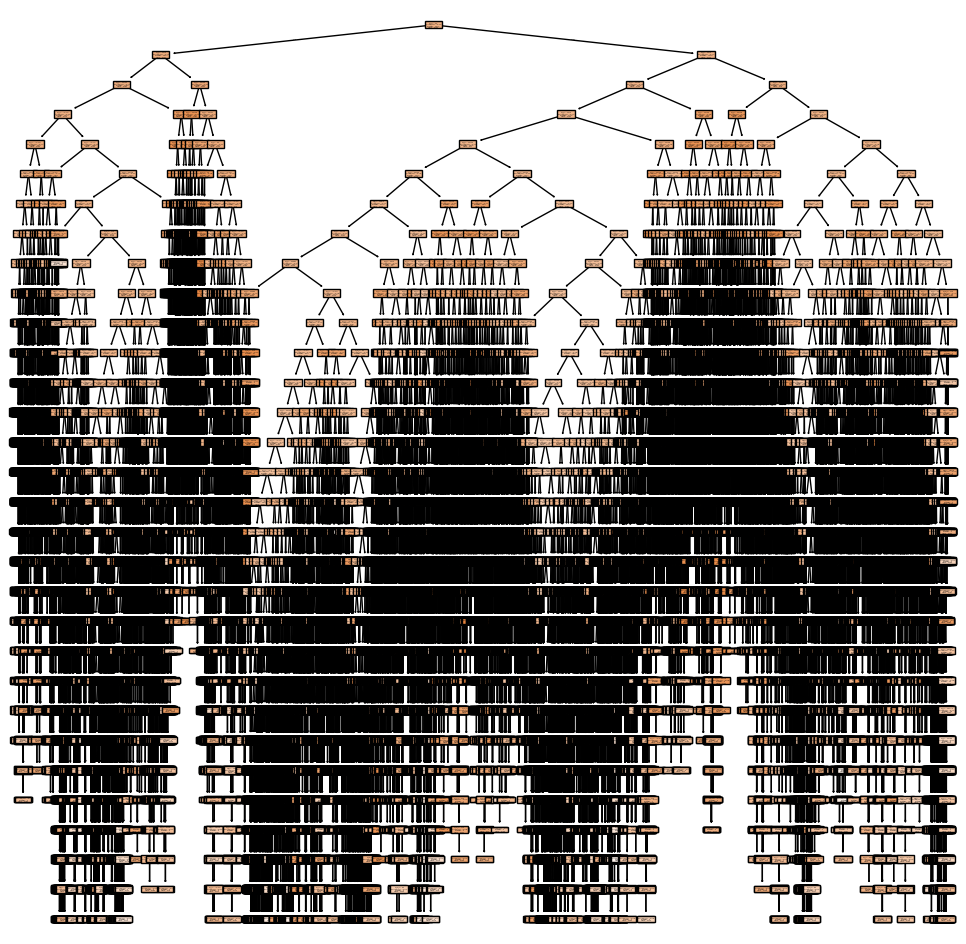

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))
plot_tree(rf_final.estimators_[0], max_depth=30, filled=True, ax=ax)
plt.show()

In [ ]:
X.head(2)

,user_type,bikeid,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,birth year,gender_1,start_hour,start_day,start_month,start_year,stop_day,stop_month,stop_year
1,1,23514,3143,40.776829,-73.963888,3132,40.763505,-73.971092,1960.0,1,0,1,1,2016,1,1,2016
2,1,14536,3164,40.777057,-73.978985,3178,40.784145,-73.983625,1971.0,1,0,1,1,2016,1,1,2016


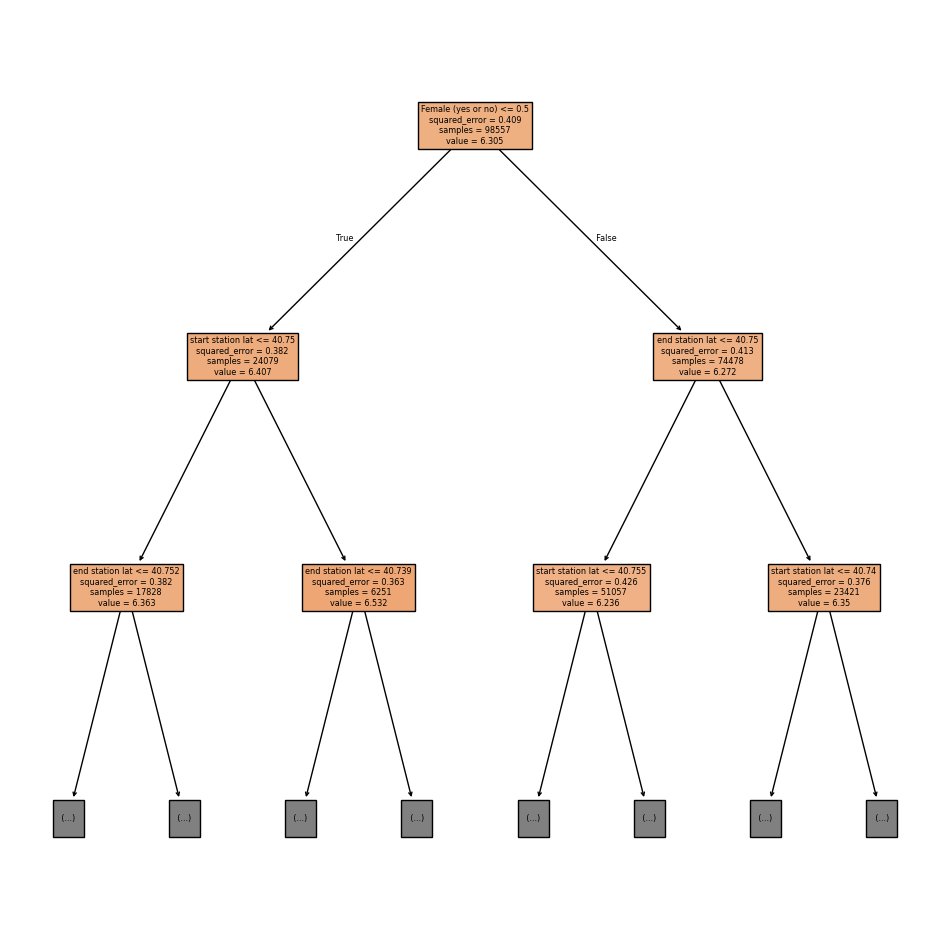

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))
plot_tree(rf_final.estimators_[0], max_depth=2, filled=True, ax=ax, feature_names = ("user_type", "biked", "stat station id", "start station lat", "start station long", "end station id", "end station lat", "end station long", "birth year", "Female (yes or no)", "start hour", "start day", "start month", "start year", "stop day", "stop month", "stop year"))
plt.show()

Plots to Visualize Model Performance

In [ ]:
from sklearn.model_selection import cross_val_predict

In [ ]:
y_pred_log = cross_val_predict(pipeline, X, y_log, cv=10)

In [ ]:
y_pred = np.exp(y_pred_log)
y_actual = np.exp(y_log)

residuals = y_actual - y_pred

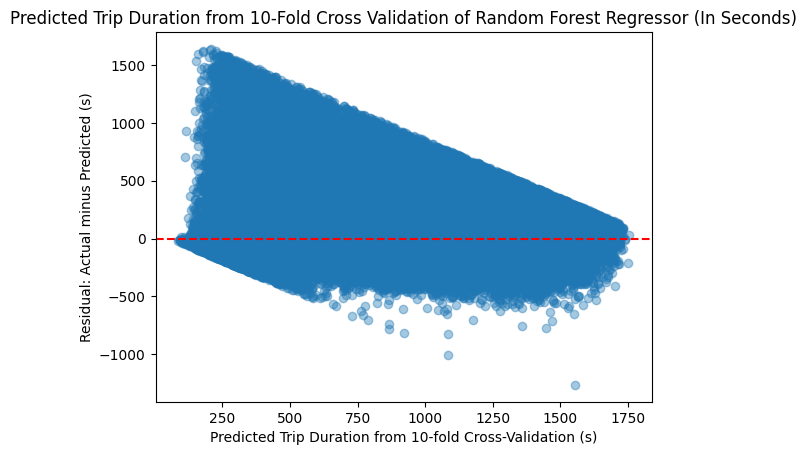

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Trip Duration from 10-fold Cross-Validation (s)")
plt.ylabel("Residual: Actual minus Predicted (s)")
plt.title("Predicted Trip Duration from 10-Fold Cross Validation of Random Forest Regressor (In Seconds)")
plt.show()

Text(0.5, 1.0, 'Predicted vs Actual Trip Duration from 10-Fold Cross Validation (in Seconds)')

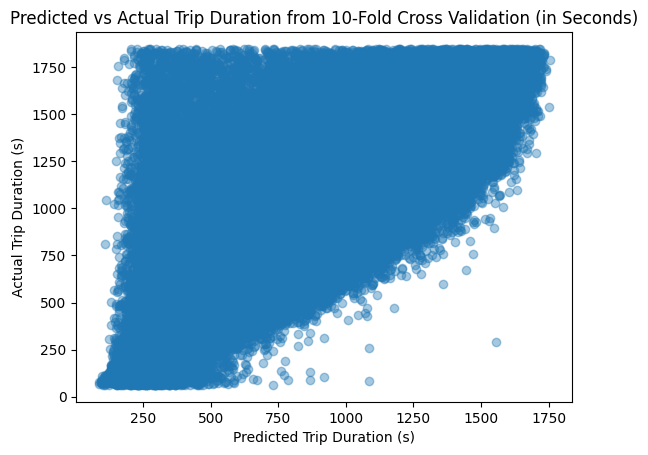

In [ ]:
plt.scatter(y_pred, y_actual, alpha=0.4)
plt.xlabel("Predicted Trip Duration (s)")
plt.ylabel("Actual Trip Duration (s)")
plt.title("Predicted vs Actual Trip Duration from 10-Fold Cross Validation (in Seconds)")

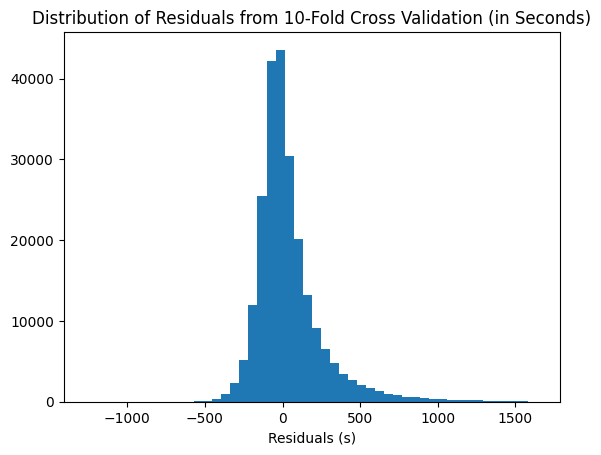

In [ ]:
plt.hist(residuals, bins=50)
plt.xlabel('Residuals (s)')
plt.title('Distribution of Residuals from 10-Fold Cross Validation (in Seconds)')
plt.show()

Importance of Predictors

In [ ]:
_df_1 = pd.DataFrame({
    'predictor': X.columns,
    'importance': rf_final.feature_importances_
})

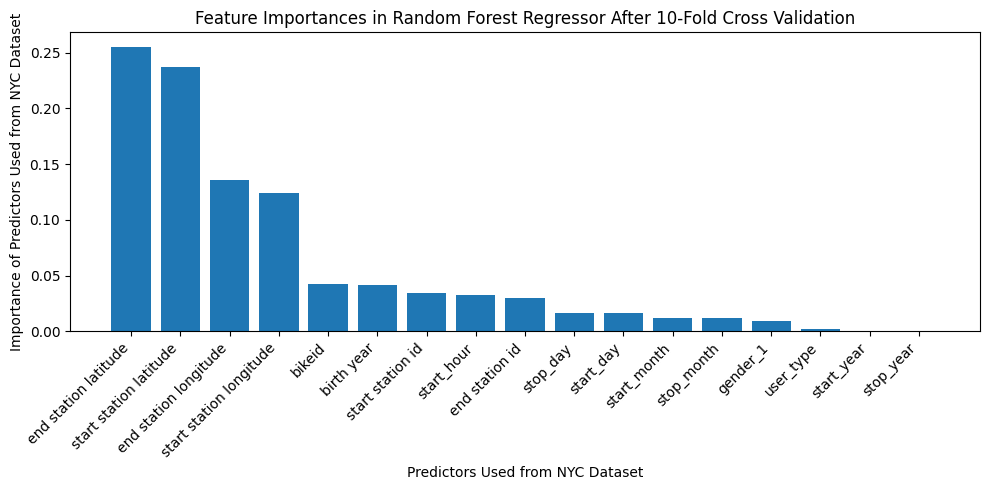

In [ ]:
_df_1 = _df_1.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(_df_1['predictor'], _df_1['importance'])
plt.title('Feature Importances in Random Forest Regressor After 10-Fold Cross Validation')
plt.xlabel('Predictors Used from NYC Dataset')
plt.ylabel('Importance of Predictors Used from NYC Dataset')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The goal of this section was to determine if a regression model could be used to predict trip duration. First, a linear regression model was created. The Mean Squared Error (MSE) was approximately 200,000 and the R^2 was 0.2. Even after applying Principal Component Analysis (PCA), L2 regularization, feature engineering and target transformations, the model was still making severely inaccurate predictions. It was hypothesized that either the data violated multiple of the fundamental assumptions of linear regression (LR)--hence why transformations and engineering did not work--or the data was too noisy for LR to capture all of the variance. This portion of the experiment is not featured in this notebook for brevity. For this code, please contact the authors.

To capture a more complex relationship between X and Y, a baseline decision tree was created. The MSE and R^2 of this model saw a significant improvement over linear regression. However, the final model selected was Random Forests, as these are very good at eliminating variance within a dataset.

The initial Random Forest Regressor (RFR) created achieved a MSE of 48,258 and an R^2 of 0.691. To linearize the relationship between X and Y, the target was log-transformed. The RFR then achieved a MSE and R^2 of 0.128 (+/- 43% of the true value) and 0.683, respectively. Clearly, the MSE still has much room for improvement.

Hyperparameter tuning was performed next. 3-fold cross validation was used to determine the optimal cost complexity pruning value (alpha), max depth, number of estimators, minimum number of splits and minimum number of leaf nodes. The most interesting observation made from this was that the optimal ccp_alpha value was found to be 0, meaning that no pruning is necessary. Typically, no pruning leads to overfitting. The model not overfitting might then suggest that the model is underfitting. The MSE and R^2, after hyperparameter tuning were found to be 0.117 (+/- 41% of the true value) and 0.71, respectively.

10-fold cross validation was used to evaluate the robustness of the model. The MSE was 0.118 (+/- 41% of the true value) and the R^2 was 0.710. The MSE increased slightly, but not enough to make a difference on the accuracy of the predictions.

An additional feature "start hour" was added. The intent behind this was to evaluate if general time of day (morning/night rush hour or lunch time) had an affect on trip duration. The 10-fold cross validated scores with "start hour" included were a MSE of 0.118 and a R^2 of 0.710. Clearly, this additional feature did not impact the accuracy of the regression model.

Finally, a few visualizations were made. Figure 1 shows th entire decision tree. The tree was expected to be large, as the optimal maximum depth was found to be 30 and no pruning was included (via cross validation of ccp_alpha). Additionally, the tree created was used on a regression problem and regression trees are often large. Often, such large trees are assumed to be overfit. However, the hyperparameter tuning found that no pruning was needed. Figure 2 is zooms in on the first 3 layers of the decision tree.

Figure 3 plots the predicted trip duration against the residuals. This graph shows a clear pattern amongst the residuals, confirming the earlier hypothesis that a fundamental assumption of linear regression was violated; in this case, the residuals are heteroscedastic. Decision trees, though, do not assume homoscedasticity, therefore no assumption was violated in the selected model. What can be inferred from this graph is that the model often predicts a trip to be shorter than it actually is. To combat this, the model should be trained on data with shorter trip durations.

Figure 4 illustrates that this model struggles to accurately predict trip durations that deviate extremely from the mean. This means that the model is regressing towards the mean and that the decision trees are struggling to capture the non-linearity of the model. Additionally, because the data used is from the real world, it is extremely noisy and so an incredibly robust model must be used to minimize the variance. To combat these issues, other models, such as neural networks and boosted decision trees with a gradient descent, should be considered.

Figure 5 shows a rightly skewed distribution centered around 0 (on the x-axis). The skew shows that the model sometimes predicts trips to be shorter than they actually are, reinforcing what was displayed in figure 3.

Figure 6 shows the importance of the predictors in the model. The latitude of the start and end stations were the most important predictors, contributing about 50% of the input, collectively. Longitude was a close second, contributing about 25% of the input. All other data points contributed less than 5% of the input.

In conclusion, a decently robust model was created, given the limitations of decision trees. Specifically, a Random Forest Regressor was used to predict trip duration. After hyperparamater tuning and 10-fold cross validation, a final MSE and R^2 of 0.118 and 71% were found, respectively. To make more accurate predictions, other models and model features that can minimize noise, capture non-linearity and manage heteroscedascity should be used.


**Conclusion**

Based on our findings, I would advise my clients to place bike stations near large, non-residential business areas and tourist hotspots, specifically focusing on the latitude of these locations. Additionally, we would suggest that our clients host promotions during peak bikeshare hours and seasons, such as 5 pm and summer, respectively.

Finally, if my clients wanted to charge prices based on the length of a bike ride, my consulting group would provide the decision tree, implemented with a user-friendly interface, to our client. From there, the client could use various attributes about frequent bikeriders to determine the proper amount to charge per minute.